Project: Amazon Sales Data Analysis

Objective: Analyze sales trends, revenue patterns, and product performance.

Tools: Python, Pandas, Matplotlib, Seaborn

Steps:
1. Data Cleaning
2. EDA
3. Visualization
4. Insights

In [1]:
#Importing Liabraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
#Extracting CSV Dataset from System using Pandas Liabrary
data = pd.read_csv(r"C:\Users\sarth\Documents\DS_f proj\1_Amazon Sales data.csv")

In [3]:
#Dataset Head Information
data.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [4]:
#All columns in a dataset
data.columns

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='object')

In [5]:
#Checking NULL values
data.isnull().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

# **There are no missing values in dataset.**

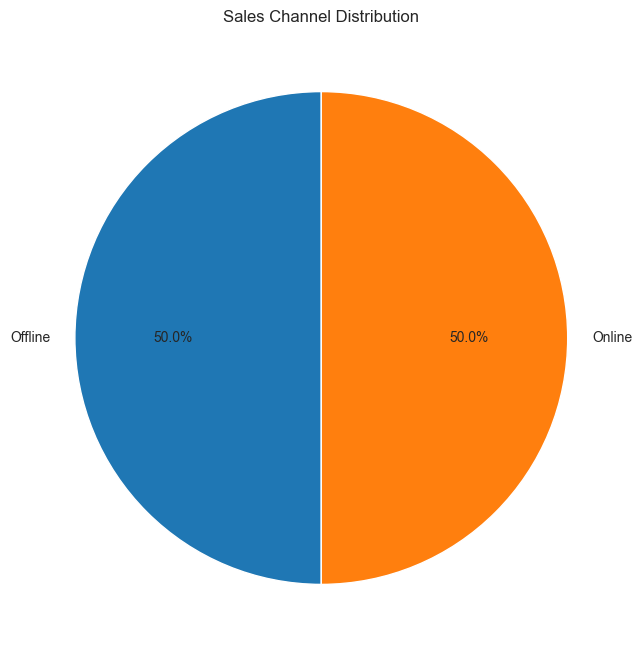

In [6]:
# Calculate the total sales for each sales channel using pie chart.
sales_channel_distribution = data['Sales Channel'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sales_channel_distribution, labels=sales_channel_distribution.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales Channel Distribution')
plt.show()

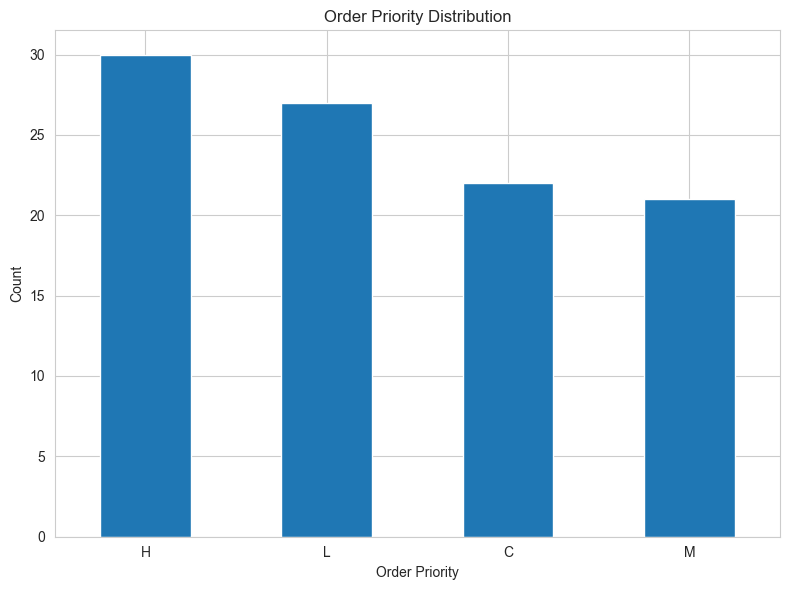

In [7]:
# Group data by order priority and count occurrences using stacked bar chart.
order_priority_distribution = data['Order Priority'].value_counts()

# Create a stacked bar chart
plt.figure(figsize=(8, 6))
order_priority_distribution.plot(kind='bar', stacked=True)
plt.xlabel('Order Priority')
plt.ylabel('Count')
plt.title('Order Priority Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

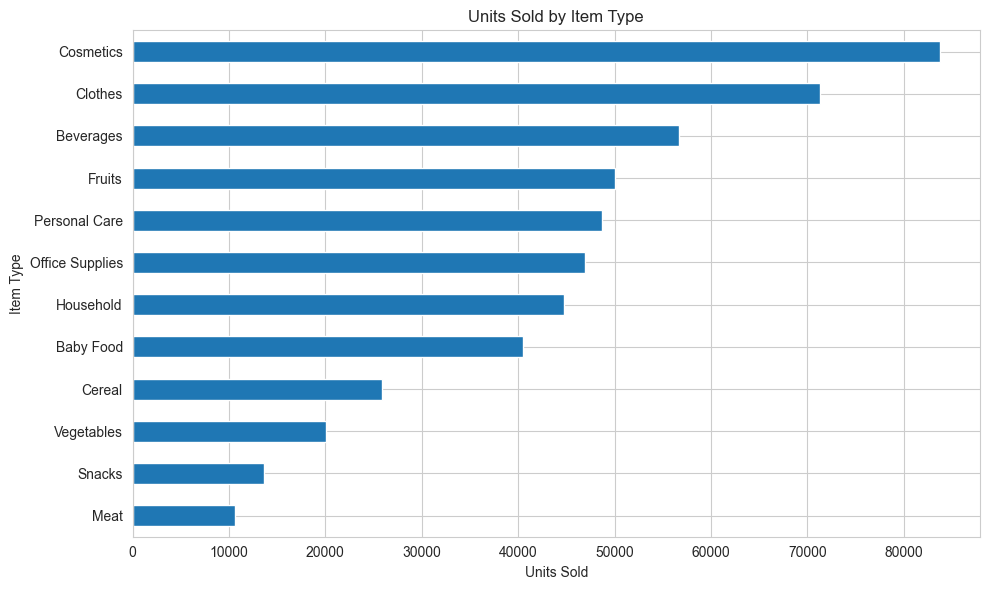

In [8]:
# Group data by item type and calculate total units sold by bar plot.
item_type_sales = data.groupby('Item Type')['Units Sold'].sum().sort_values(ascending=True)

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))
item_type_sales.plot(kind='barh')
plt.ylabel('Item Type')
plt.xlabel('Units Sold')
plt.title('Units Sold by Item Type')
plt.tight_layout()
plt.show()

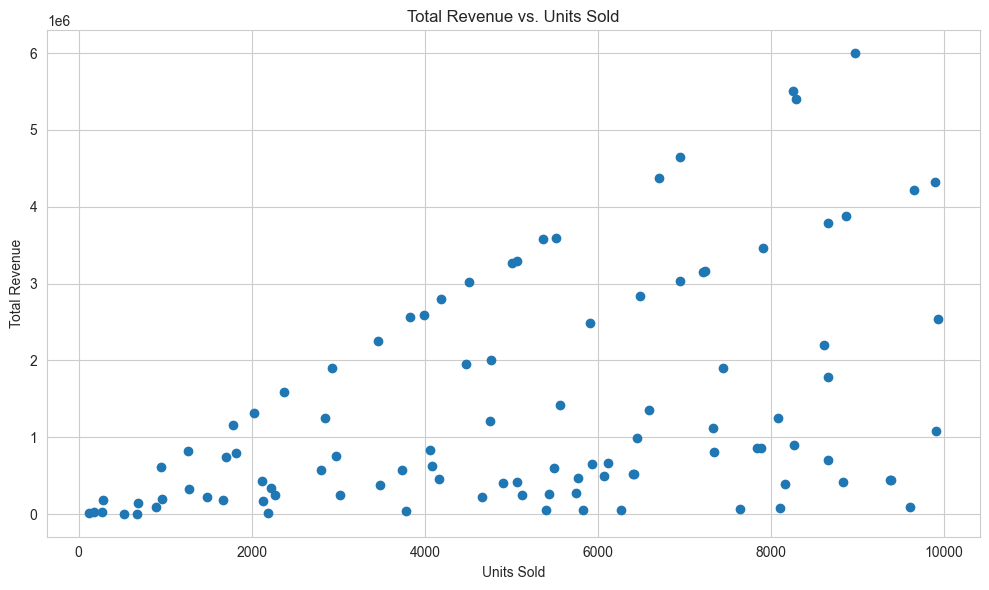

In [9]:
# Total Revenue vs units sold by scatter plot.
plt.figure(figsize=(10, 6))
plt.scatter(data['Units Sold'], data['Total Revenue'])
plt.xlabel('Units Sold')
plt.ylabel('Total Revenue')
plt.title('Total Revenue vs. Units Sold')
plt.grid(True)
plt.tight_layout()
plt.show()

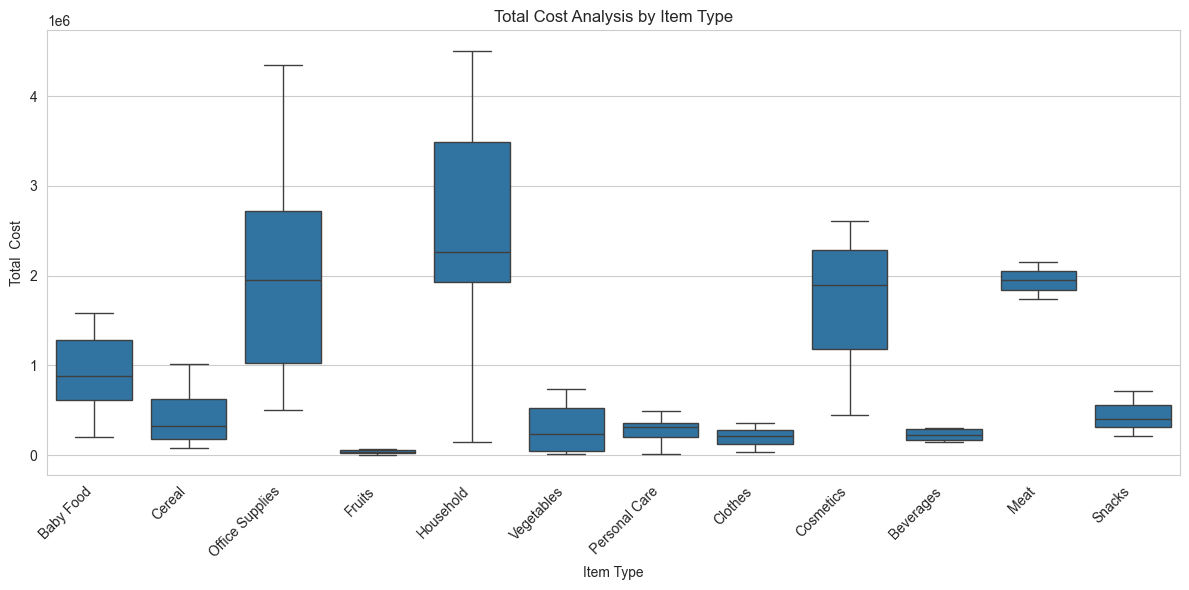

In [10]:
# Analysis of cost analysis by item type by box plot.
plt.figure(figsize=(12, 6))
sns.boxplot(x='Item Type', y='Total Cost', data=data)
plt.xlabel('Item Type')
plt.ylabel('Total  Cost')
plt.title('Total Cost Analysis by Item Type')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

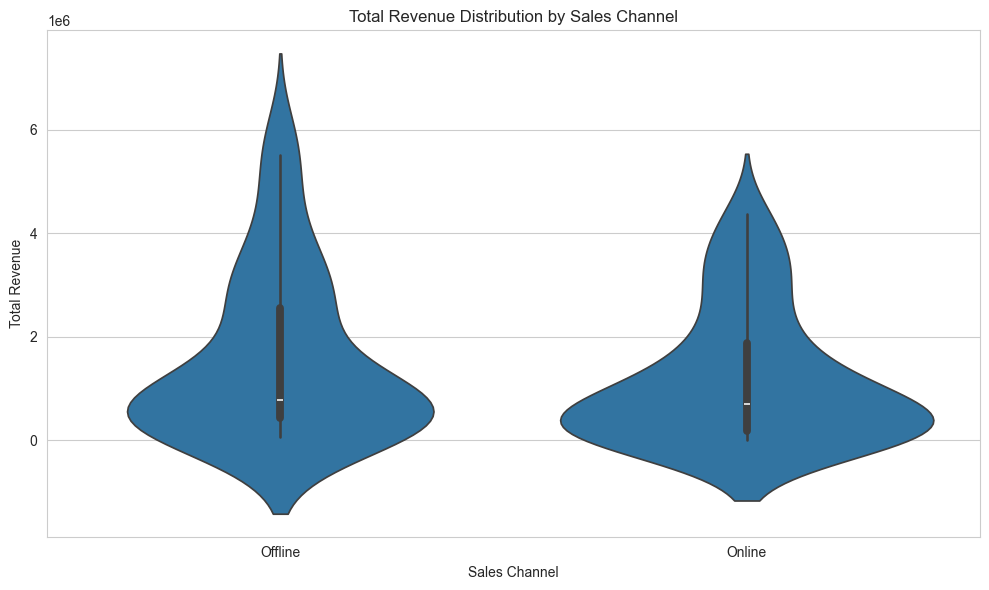

In [11]:
# Analysis of revenue distribution by sales channel using violin plot.
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sales Channel', y='Total Revenue', data=data)
plt.xlabel('Sales Channel')
plt.ylabel('Total Revenue')
plt.title('Total Revenue Distribution by Sales Channel')
plt.tight_layout()
plt.show()

<Axes: >

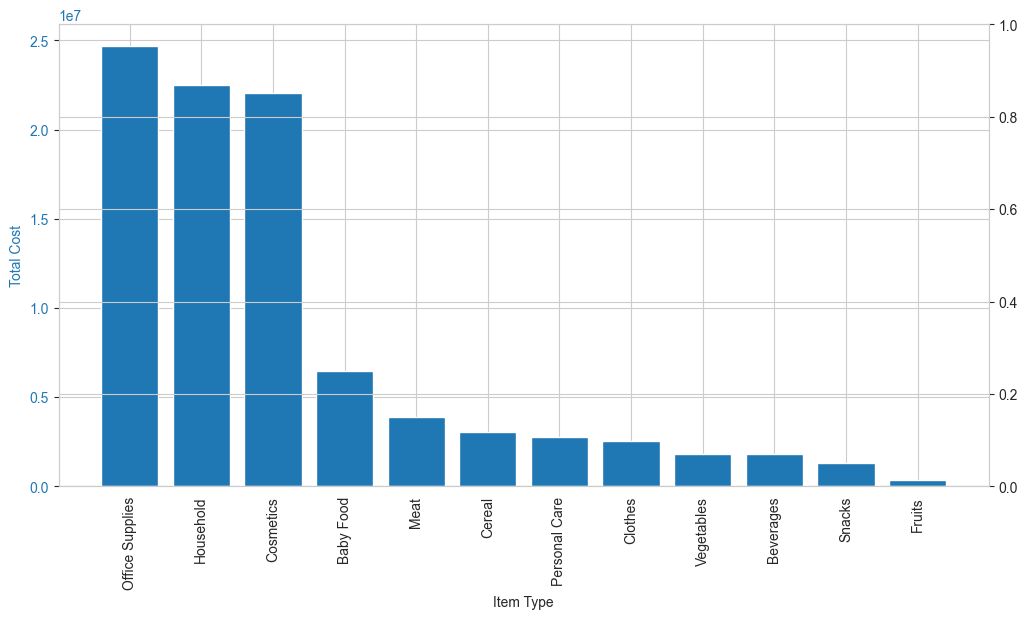

In [12]:
# Group data by product and calculate total sale using pareto chart ( cumulative bar chart)
product_sales = data.groupby('Item Type')['Total Cost'].sum().sort_values(ascending=False)

# Calculate cumulative sales and percentage
cumulative_sales = product_sales.cumsum()
total_sales = cumulative_sales.iloc[-1]
cumulative_percentage = (cumulative_sales / total_sales) * 100

# Create a Pareto chart (cumulative bar chart)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for sales
ax1.bar(product_sales.index, product_sales.values, color='tab:blue')
ax1.set_xlabel('Item Type')
ax1.set_ylabel('Total Cost', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.xticks(rotation=90)

# Line chart for cumulative percentage
ax2 = ax1.twinx()
ax2

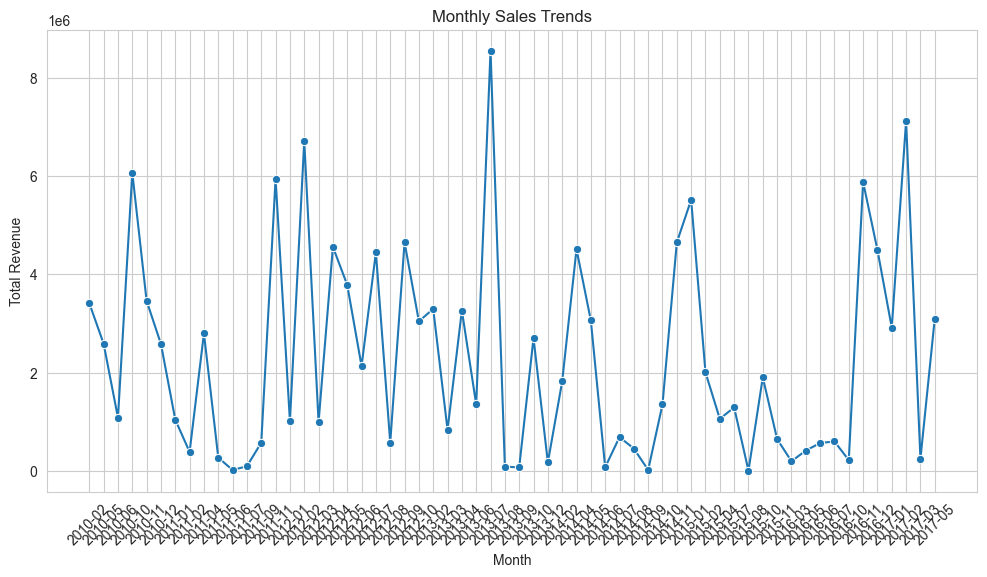

In [13]:
# Monthly Sales Trend using line chart.
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')

# Extract month and year for grouping
data['Month'] = data['Order Date'].dt.to_period('M')

# Group by month and sum the total revenue
monthly_sales = data.groupby('Month')['Total Revenue'].sum().reset_index()

# Convert 'Month' column to string for plotting # This is the change
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# Plot the monthly sales trends
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Total Revenue', data=monthly_sales, marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

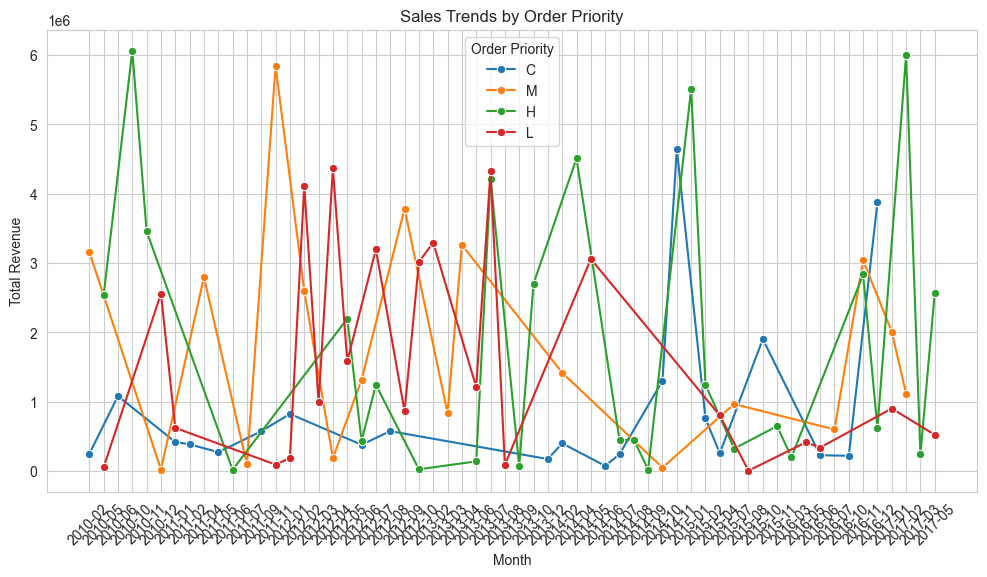

In [14]:
# Sales Trend by order priority using line chart.
priority_monthly_sales = data.groupby(['Month', 'Order Priority'])['Total Revenue'].sum().reset_index()

# Convert 'Month' from Period to string for plotting
priority_monthly_sales['Month'] = priority_monthly_sales['Month'].astype(str)

# Plot the sales trends by order priority
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Total Revenue', hue='Order Priority', data=priority_monthly_sales, marker='o')
plt.xticks(rotation=45)
plt.title('Sales Trends by Order Priority')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.legend(title='Order Priority')
plt.grid(True)
plt.show()